In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_palette("Set2")

In [2]:
df = pd.read_csv("books.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# Display First 5 Rows
df.head()

,Title,Price_GBP,Rating,Availability,Product_URL
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...


In [4]:
# Missing Values

df.isnull().sum()

Title           0
Price_GBP       0
Rating          0
Availability    0
Product_URL     0
dtype: int64

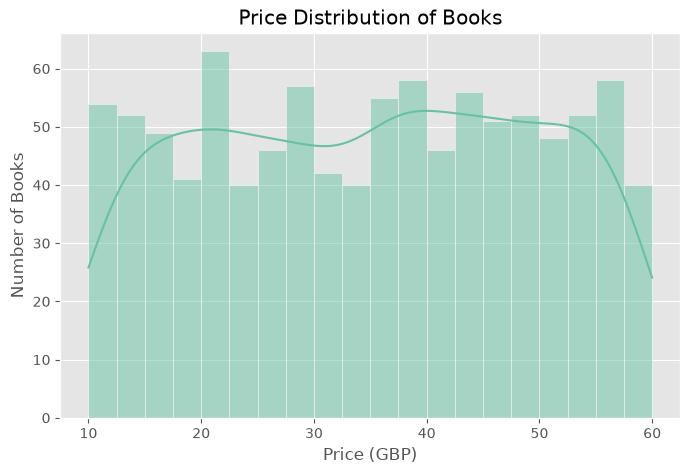

In [5]:
# Price Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Price_GBP"], bins=20, kde=True)

plt.title("Price Distribution of Books")
plt.xlabel("Price (GBP)")
plt.ylabel("Number of Books")

plt.savefig("screenshots/price_distribution.jpeg",
            dpi=300,
            bbox_inches="tight")

plt.show()

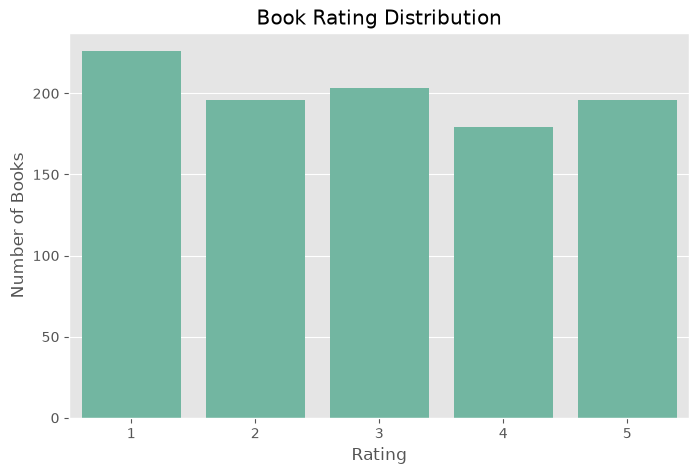

In [6]:
# Rating Distribution

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Rating")

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.savefig("screenshots/rating_distribution.jpeg",
            dpi=300,
            bbox_inches="tight")

plt.show()

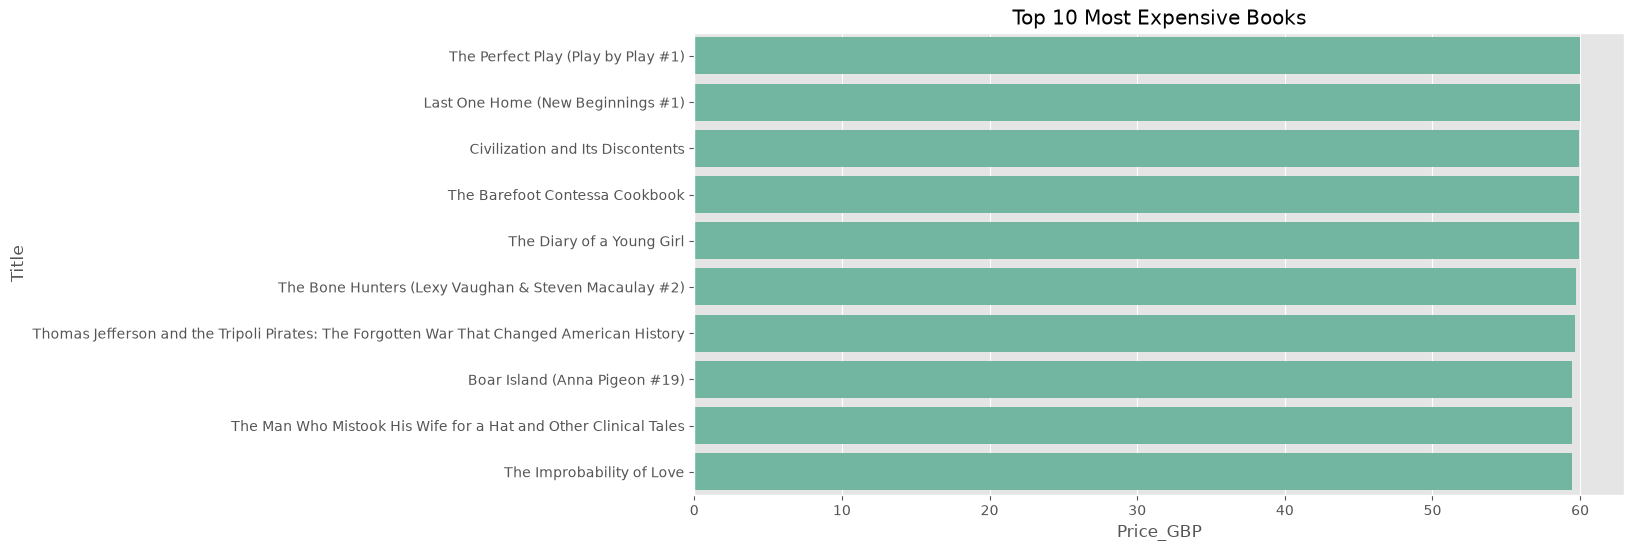

In [7]:
# Top 10 Most Expensive Books

top_books = df.sort_values(by="Price_GBP", ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_books,
    x="Price_GBP",
    y="Title"
)

plt.title("Top 10 Most Expensive Books")

plt.savefig("screenshots/top10_books.jpeg",
            dpi=300,
            bbox_inches="tight")

plt.show()

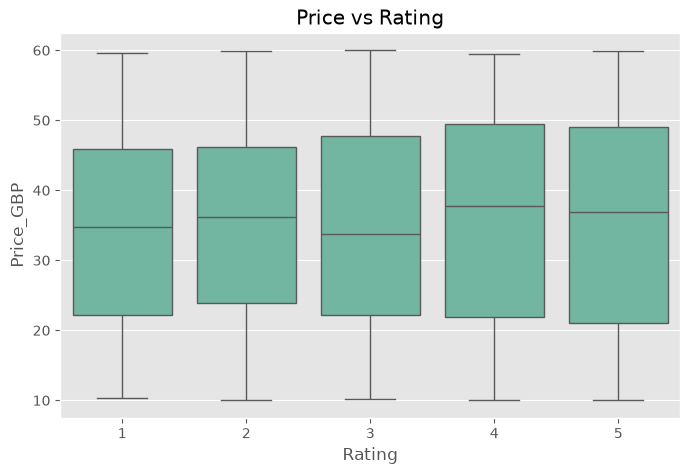

In [8]:
# Price vs Rating

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Rating",
    y="Price_GBP"
)

plt.title("Price vs Rating")

plt.savefig("screenshots/boxplot_rating_price.jpeg",
            dpi=300,
            bbox_inches="tight")

plt.show()

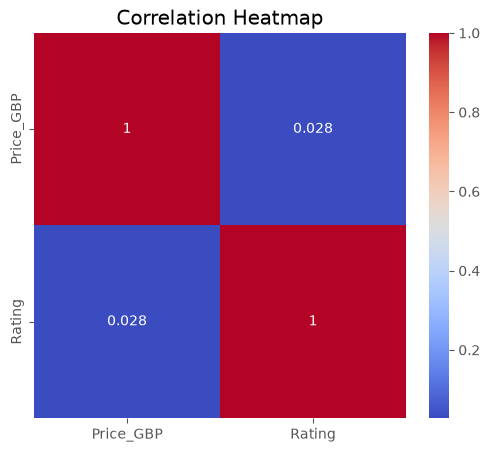

In [9]:
# Correlation Heatmap

plt.figure(figsize=(6,5))

sns.heatmap(
    df[["Price_GBP", "Rating"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("screenshots/correlation_heatmap.jpeg",
            dpi=300,
            bbox_inches="tight")

plt.show()

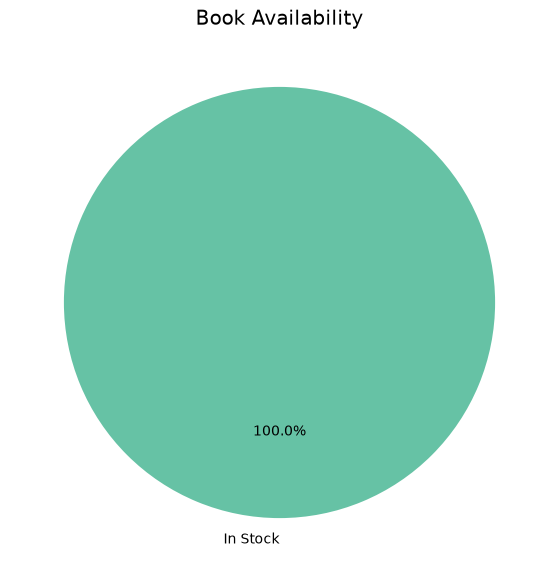

In [10]:
# Book Availability (Pie Chart)

# Convert all "In stock (...)" values into one category
availability = df["Availability"].apply(
    lambda x: "In Stock" if "In stock" in str(x) else "Out of Stock"
)

availability_counts = availability.value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    availability_counts,
    labels=availability_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66c2a5", "#fc8d62"]
)

plt.title("Book Availability")

plt.savefig(
    "screenshots/availability_pie.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

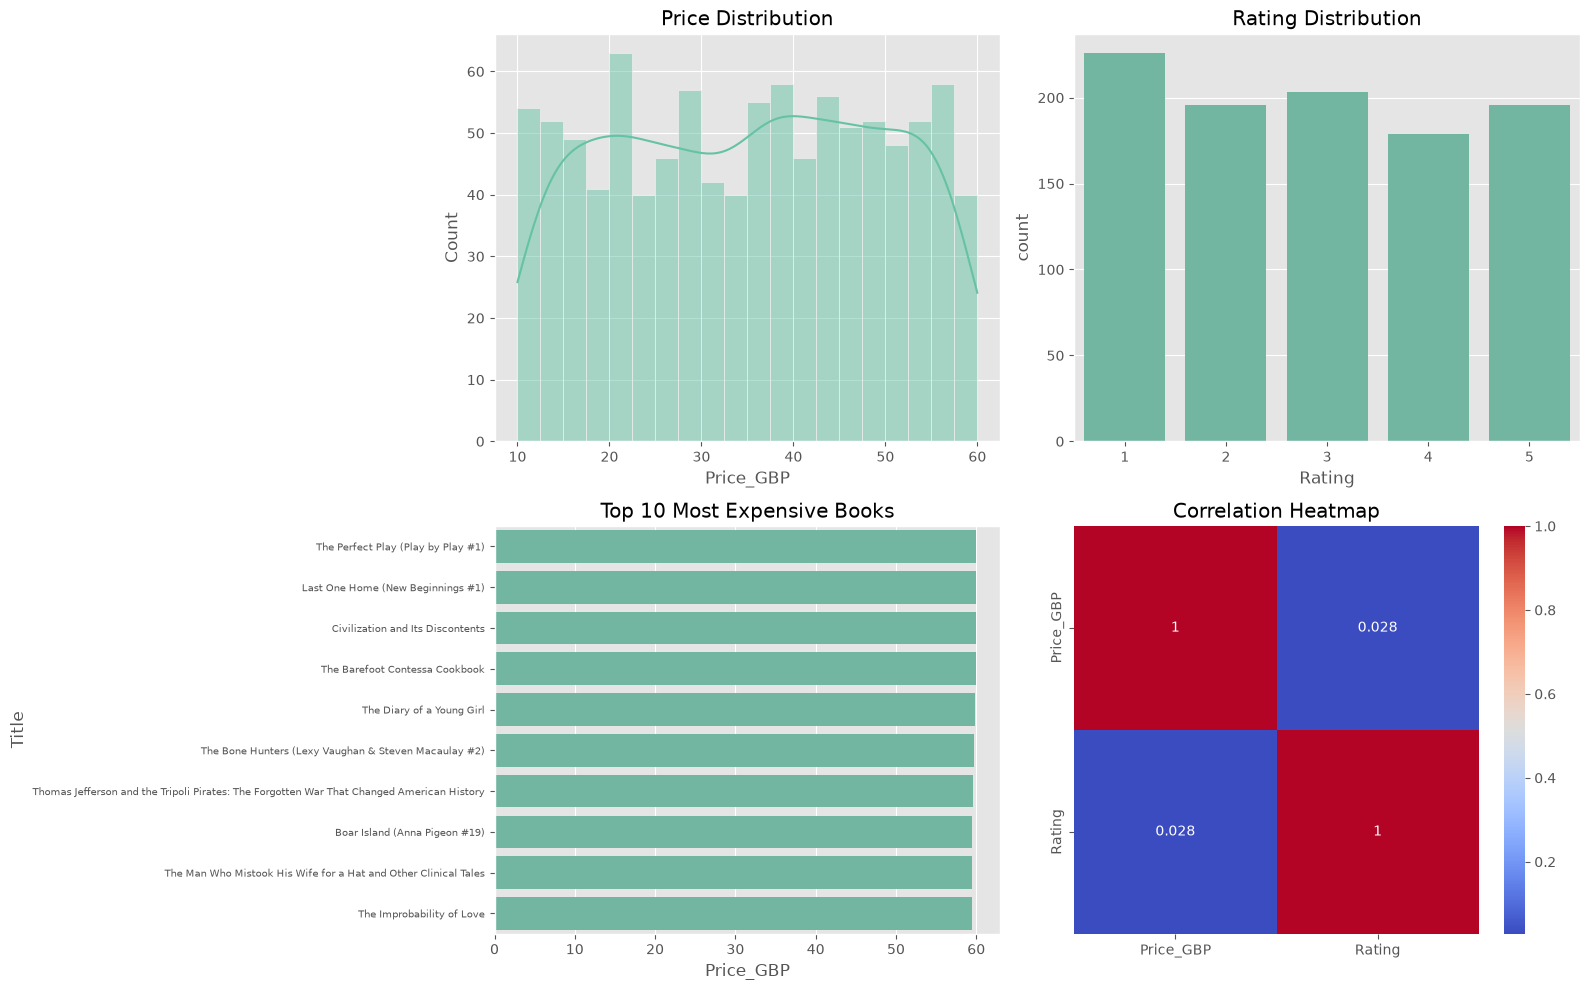

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Price Distribution
sns.histplot(df["Price_GBP"], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title("Price Distribution")

# Rating Distribution
sns.countplot(data=df, x="Rating", ax=axes[0,1])
axes[0,1].set_title("Rating Distribution")

# Top 10 Expensive Books
top_books = df.sort_values(by="Price_GBP", ascending=False).head(10)

sns.barplot(
    data=top_books,
    x="Price_GBP",
    y="Title",
    ax=axes[1,0]
)
axes[1,0].set_title("Top 10 Most Expensive Books")
axes[1,0].tick_params(axis='y', labelsize=7)

# Correlation
sns.heatmap(
    df[["Price_GBP","Rating"]].corr(),
    annot=True,
    cmap="coolwarm",
    ax=axes[1,1]
)
axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "screenshots/dashboard.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Business Story

print("=" * 60)
print("BOOK STORE DATA VISUALIZATION - BUSINESS STORY")
print("=" * 60)

print("\n1. Price Analysis")
print("- Book prices range from approximately £10 to £60.")
print("- Most books are moderately priced, with only a few expensive books.")

print("\n2. Rating Analysis")
print("- Most books have ratings between 2 and 4 stars.")
print("- Five-star books are relatively fewer.")

print("\n3. Price vs Rating")
print("- There is very little correlation between price and rating.")
print("- Expensive books are not necessarily highly rated.")

print("\n4. Availability")
print("- Nearly all books are currently in stock.")
print("- Inventory management appears to be efficient.")

print("\n5. Business Recommendations")
print("- Promote highly rated books regardless of price.")
print("- Offer discounts on expensive books to increase sales.")
print("- Maintain adequate stock levels for popular books.")
print("- Use customer ratings to improve recommendation systems.")

print("\nDashboard successfully summarizes the overall dataset and supports business decision-making.")

BOOK STORE DATA VISUALIZATION - BUSINESS STORY

1. Price Analysis
- Book prices range from approximately £10 to £60.
- Most books are moderately priced, with only a few expensive books.

2. Rating Analysis
- Most books have ratings between 2 and 4 stars.
- Five-star books are relatively fewer.

3. Price vs Rating
- There is very little correlation between price and rating.
- Expensive books are not necessarily highly rated.

4. Availability
- Nearly all books are currently in stock.
- Inventory management appears to be efficient.

5. Business Recommendations
- Promote highly rated books regardless of price.
- Offer discounts on expensive books to increase sales.
- Maintain adequate stock levels for popular books.
- Use customer ratings to improve recommendation systems.

Dashboard successfully summarizes the overall dataset and supports business decision-making.
